<a href="https://colab.research.google.com/github/chidimo/AI-MSc/blob/main/mldm_wk6_fetal_wellbeing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
cardio_data = pd.read_csv('Cardiotocographic.csv')
print(cardio_data.info(), end='\n\n')
print(cardio_data.shape, end='\n\n')
cardio_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BPM     2126 non-null   int64  
 1   APC     2126 non-null   float64
 2   FMPS    2126 non-null   float64
 3   UCPS    2126 non-null   float64
 4   DLPS    2126 non-null   float64
 5   SDPS    2126 non-null   float64
 6   PDPS    2126 non-null   float64
 7   ASTV    2126 non-null   int64  
 8   MSTV    2126 non-null   float64
 9   ALTV    2126 non-null   int64  
 10  MLTV    2126 non-null   float64
 11  Width   2126 non-null   int64  
 12  Min     2126 non-null   int64  
 13  Max     2126 non-null   int64  
 14  NSP     2126 non-null   int64  
dtypes: float64(8), int64(7)
memory usage: 249.3 KB
None

(2126, 15)



,BPM,APC,FMPS,UCPS,DLPS,SDPS,PDPS,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003170,0.009474,0.004357,0.001885,0.000004,0.000157,46.990122,1.332785,9.84666,8.187629,70.445908,93.579492,164.025400,1.304327
std,9.840844,0.003860,0.046670,0.002940,0.002962,0.000063,0.000580,17.192814,0.883241,18.39688,5.628247,38.955693,29.560212,17.944183,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,0.000000,3.000000,50.000000,122.000000,1.000000
25%,126.000000,0.000000,0.000000,0.001876,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,4.600000,37.000000,67.000000,152.000000,1.000000
50%,133.000000,0.001630,0.000000,0.004482,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,7.400000,67.500000,93.000000,162.000000,1.000000
75%,140.000000,0.005631,0.002512,0.006525,0.003264,0.000000,0.000000,61.000000,1.700000,11.00000,10.800000,100.000000,120.000000,174.000000,1.000000
max,160.000000,0.019284,0.480634,0.014925,0.015385,0.001353,0.005348,87.000000,7.000000,91.00000,50.700000,180.000000,159.000000,238.000000,3.000000


In [ ]:
cardio_data['NSP'].value_counts()

,count
NSP,
1,1655
2,295
3,176


/tmp/ipython-input-220997538.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='NSP', data=cardio_data, palette=['blue', 'green', 'red'])


<Axes: xlabel='NSP', ylabel='count'>

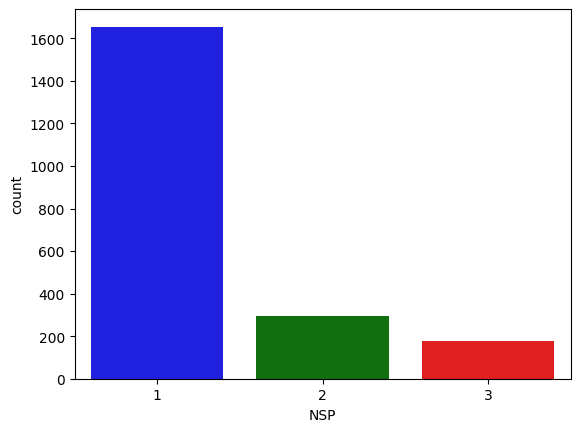

In [ ]:
sns.countplot(x='NSP', data=cardio_data, palette=['blue', 'green', 'red'])

In [ ]:
X = cardio_data.drop('NSP', axis=1)
y = cardio_data['NSP'] - 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_test.shape, end='------------------\n\n')
print(X_train.shape)

(426, 14)------------------

(1700, 14)


## Build and train the Neural Network

In [ ]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(9, activation='relu', input_shape=(14, )))
model.add(tf.keras.layers.Dense(3, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 9)              │           135 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 200
class_weights = {0: 1, 1: 5.6, 2: 9.4}

history = model.fit(
    X_train,
    np.asarray(y_train),
    batch_size=32,
    epochs=epochs,
    verbose=2,
    class_weight=class_weights,
    validation_split=0.2
)

Epoch 1/200
43/43 - 3s - 74ms/step - accuracy: 0.3919 - loss: 2.4508 - val_accuracy: 0.4324 - val_loss: 1.1229
Epoch 2/200
43/43 - 0s - 4ms/step - accuracy: 0.4875 - loss: 2.1803 - val_accuracy: 0.4941 - val_loss: 0.9864
Epoch 3/200
43/43 - 0s - 4ms/step - accuracy: 0.5529 - loss: 1.9740 - val_accuracy: 0.5706 - val_loss: 0.8777
Epoch 4/200
43/43 - 0s - 4ms/step - accuracy: 0.6110 - loss: 1.8086 - val_accuracy: 0.6471 - val_loss: 0.7916
Epoch 5/200
43/43 - 0s - 4ms/step - accuracy: 0.6816 - loss: 1.6762 - val_accuracy: 0.7029 - val_loss: 0.7226
Epoch 6/200
43/43 - 0s - 4ms/step - accuracy: 0.7176 - loss: 1.5659 - val_accuracy: 0.7382 - val_loss: 0.6637
Epoch 7/200
43/43 - 0s - 4ms/step - accuracy: 0.7397 - loss: 1.4729 - val_accuracy: 0.7500 - val_loss: 0.6172
Epoch 8/200
43/43 - 0s - 7ms/step - accuracy: 0.7485 - loss: 1.3971 - val_accuracy: 0.7559 - val_loss: 0.5847
Epoch 9/200
43/43 - 0s - 4ms/step - accuracy: 0.7632 - loss: 1.3291 - val_accuracy: 0.7765 - val_loss: 0.5513
Epoch 10/

## Evaluate the Neural Network

In [ ]:
print(history.history)

{'accuracy': [0.3919117748737335, 0.48750001192092896, 0.5529412031173706, 0.6110293865203857, 0.6816176176071167, 0.7176470756530762, 0.7397058606147766, 0.7485294342041016, 0.7632352709770203, 0.7764706015586853, 0.7875000238418579, 0.7977941036224365, 0.7992647290229797, 0.8095588088035583, 0.8102940917015076, 0.8161764740943909, 0.8198529481887817, 0.8220587968826294, 0.8257352709770203, 0.8279411792755127, 0.8294117450714111, 0.833088219165802, 0.8286764621734619, 0.8308823704719543, 0.8316176533699036, 0.8323529362678528, 0.8308823704719543, 0.8301470875740051, 0.8338235020637512, 0.8352941274642944, 0.841176450252533, 0.841911792755127, 0.841911792755127, 0.8433823585510254, 0.8470588326454163, 0.846323549747467, 0.8433823585510254, 0.8441176414489746, 0.8470588326454163, 0.8477941155433655, 0.845588207244873, 0.8485293984413147, 0.8477941155433655, 0.845588207244873, 0.8470588326454163, 0.8485293984413147, 0.8485293984413147, 0.8485293984413147, 0.8500000238418579, 0.8485293984

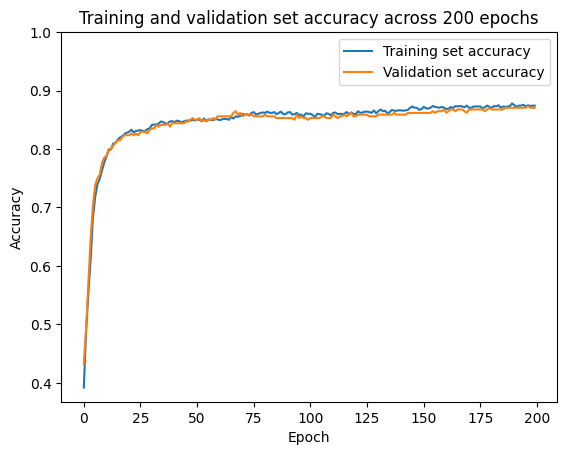

In [ ]:
train_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

plt.plot(train_accuracy, label='Training set accuracy')
plt.plot(validation_accuracy, label='Validation set accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.ylim([min(plt.ylim()), 1])
plt.title(f'Training and validation set accuracy across {epochs} epochs')
plt.legend()


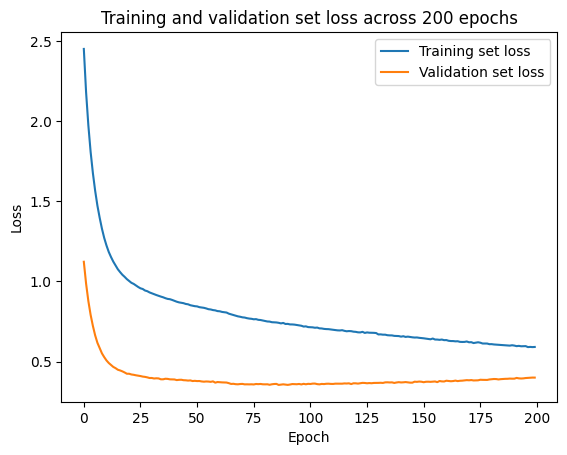

In [ ]:
train_loss = history.history['loss']
validation_loss = history.history['val_loss']
plt.plot(train_loss, label='Training set loss')
plt.plot(validation_loss, label='Validation set loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title(f'Training and validation set loss across {epochs} epochs')
plt.legend()


## Metrics

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)
print(y_pred, y_pred.shape, end='\n\n')
y_pred = np.argmax(y_pred, axis=1)
print(y_pred.shape, y_pred)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[2.7610764e-02 9.7139949e-01 9.8977424e-04]
 [9.9999988e-01 1.3053908e-07 4.2778900e-09]
 [9.8499805e-01 1.4906964e-02 9.5049203e-05]
 ...
 [9.9273407e-01 3.3071747e-03 3.9586416e-03]
 [9.9995744e-01 4.1094092e-05 1.4755667e-06]
 [9.9936867e-01 5.4320355e-04 8.8036824e-05]] (426, 3)

(426,) [1 0 0 1 1 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 2 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 2 0 0 1 0 0 1 2 0 0 0 2 0 0 0 1 2 0 0 0 0 0 1 0 1 0
 0 0 1 0 2 2 2 0 1 0 0 0 0 1 1 0 0 1 2 0 0 0 0 0 1 0 1 0 0 0 0 1 1 0 1 1 0
 0 0 0 0 1 0 0 2 0 0 0 1 0 0 0 0 1 0 0 0 1 0 2 0 0 0 1 0 0 0 0 0 0 0 1 1 0
 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 2 0 2 2 1 0 0
 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 2 1 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 2 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 1 1 0 0 1
 0 1 0 1 1 0 1 1 2 1 0 0 0 0 1 1 2 0 0 0 1 1 1 2 0 0 1 1 0 0 0 0 1 0 0 1 2
 0 0 0 0 0 0 1 0 2 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 2 0 0 1 

In [ ]:
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[288  39   5]
 [  2  52   5]
 [  4   4  27]]


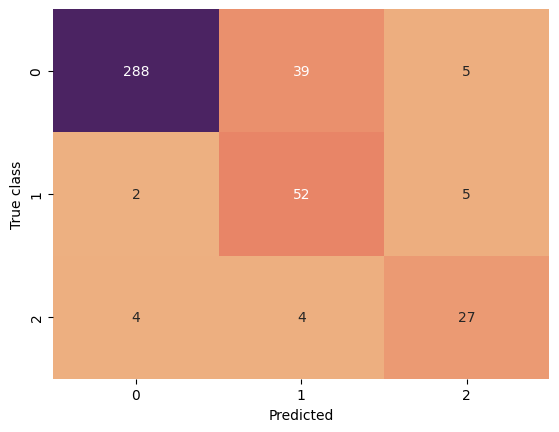

In [ ]:
ax = sns.heatmap(confusion_matrix, cmap='flare', annot=True, fmt='d', cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('True class')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.87      0.92       332
           1       0.55      0.88      0.68        59
           2       0.73      0.77      0.75        35

    accuracy                           0.86       426
   macro avg       0.75      0.84      0.78       426
weighted avg       0.90      0.86      0.87       426



Imagine that this model was going to be used to screen pregnancies to identify those which need further medical attention. In this hypothetical scenario, it is important that as many Suspect and Pathologic cases are identified as possible. Given this, what evaluation metric(s) would you recommend using to compare the performance of different models?

> I would use the recall metric as it is the one with highest scores for the Suspect and Pathologic cases.